In [1]:
# Preamble
try:
    %matplotlib inline
    %config InlineBackend.figure_format='retina'
except:
    pass

# Basic packages
import numpy as np
import glob
import ast
from astropy.table import Table
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
vr_log_files = glob.glob('logs/*.log')
vr_log_files.sort()

In [3]:
def yymmdd_to_mjd(yymmdd):
    yymmdd = str(yymmdd)
    year = int(yymmdd[:2]) + 2000
    month = int(yymmdd[2:4])
    day = int(yymmdd[4:6])
    
    dt = datetime(year, month, day)
    
    # MJD = JD - 2400000.5
    # JD from datetime:
    mjd = (dt - datetime(1858, 11, 17)).days
    return mjd

In [8]:
dates = []
mjds = []
shifts = dict()
shifts['ccd_1_0'] = []
shifts['ccd_1_1'] = []
shifts['ccd_2_0'] = []
shifts['ccd_2_1'] = []
shifts['ccd_3_0'] = []
shifts['ccd_3_1'] = []

for log_file in vr_log_files:
    date = log_file[12:18]
    print(date)
    with open(log_file, "r") as f:
        for line in f:
            if "ccd_1" in line and "ccd_2" in line and "ccd_3" in line:
                d = ast.literal_eval(line.strip())
                mjds.append(yymmdd_to_mjd(date))
                dates.append(date)

                for ccd in ['1','2','3']:
                    for xy in [0,1]:
                        if abs(float(d['ccd_'+ccd][xy])) < 10.:
                            shifts['ccd_'+ccd+'_'+str(xy)].append(float(d['ccd_'+ccd][xy]))
                        else:
                            shifts['ccd_'+ccd+'_'+str(xy)].append(np.nan)

pixel_shifts = Table()
pixel_shifts['date'] = dates
pixel_shifts['mjd'] = mjds
for ccd in ['1','2','3']:
    pixel_shifts['ccd_'+ccd+'_x'] = shifts['ccd_'+ccd+'_0']
    pixel_shifts['ccd_'+ccd+'_y'] = shifts['ccd_'+ccd+'_1']

231121
231122
231203
231204
231221
240103
240104
240118
240119
240120
240121
240122
240123
240124
240125
240126
240127
240128
240129
240130
240131
240201
240202
240203
240204
240205
240206
240219
240220
240221
240222
240223
240224
240225
240226
240227
240228
240229
240320
240321
240322
240323
240324
240418
240620
240621
240622
240919
240920
240921
250111
250112
250113
250114
250128
250129
250130
250131
250201
250202
250207
250208
250210
250211
250212
250213
250214
250215
250216
250217
250218
250219
250220
250221
250222
250223
250224
250315
250316
250602
250604
250605
250606
250606
250607
250608
250609
250610
250611
250612
250613
250614
250615
250615
250620
250621
250622
250623
250624
250629
250630
250701
250702
250703
250704
250705
250706
250707
250708
250709
250710
250711
250712
250713
250714
250715
251001
251002
251003
251004
251005
251006
251007
251009
251010
251011
251012
251029
251030
251031
251101
251102
251103
251104
251105
251106
251107
251108
251109
260104
260105
260106
260107

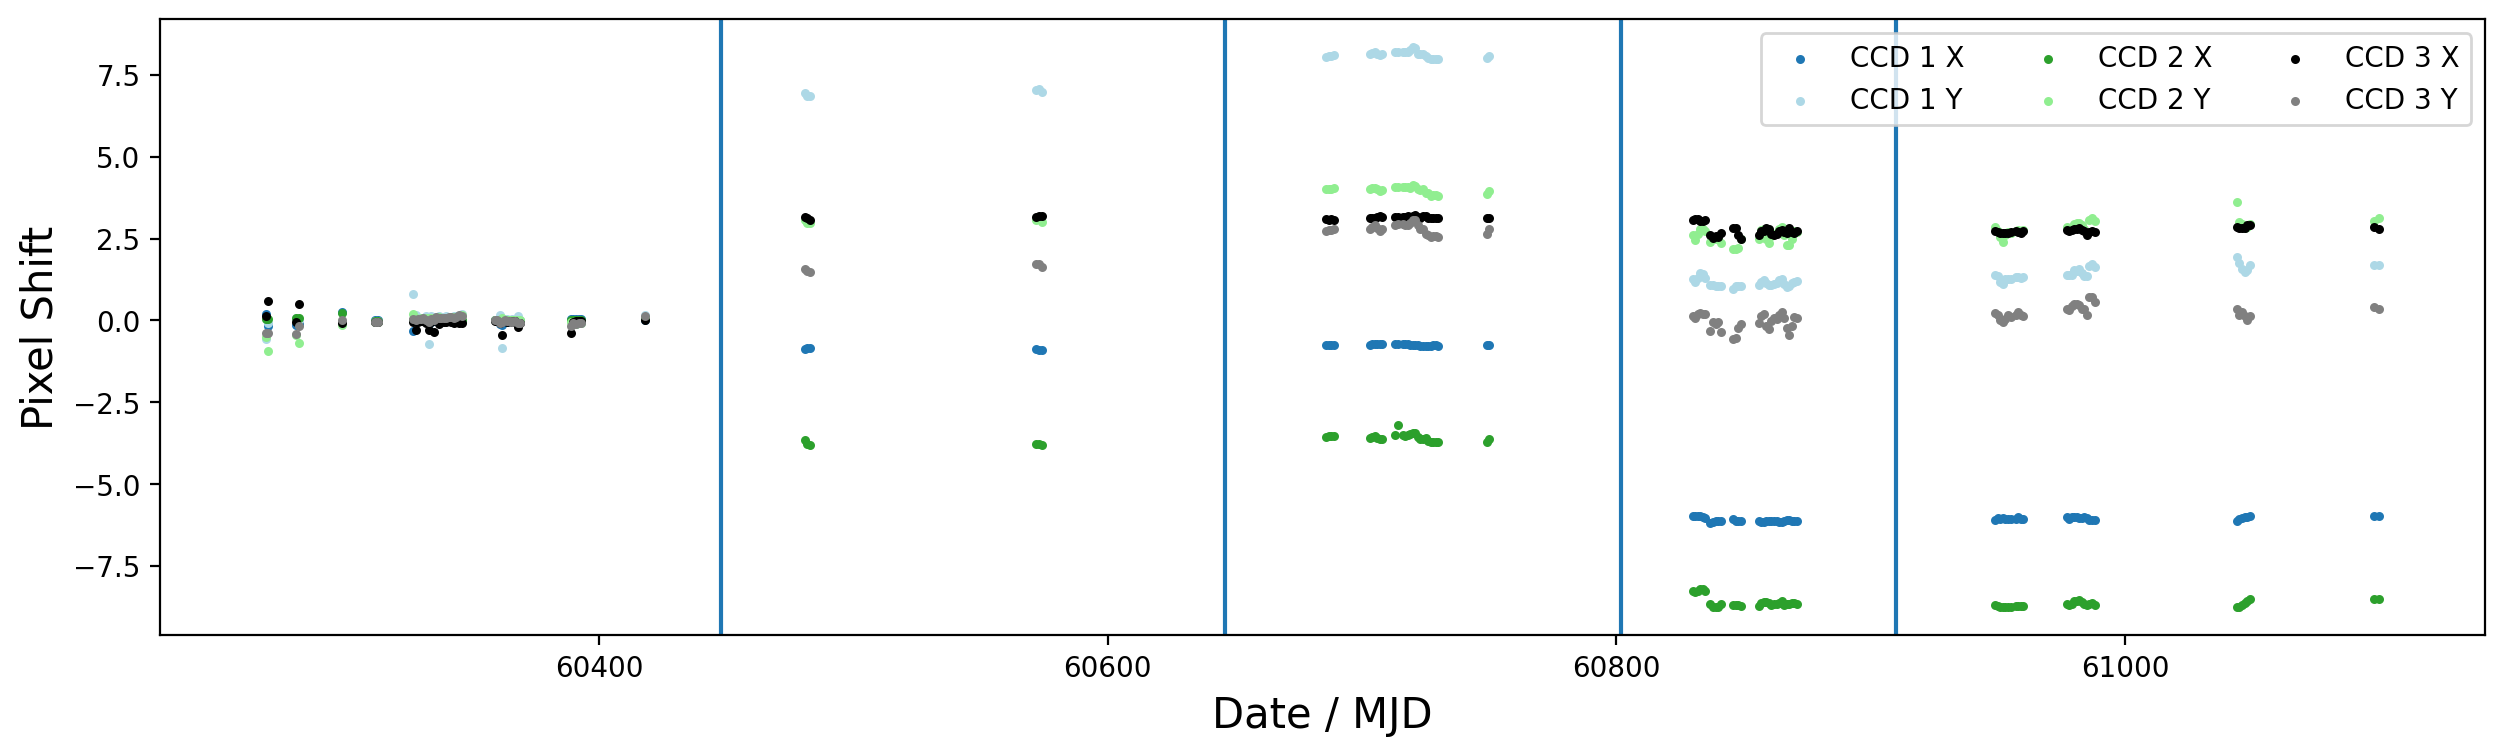

In [12]:
colors = ['C0','lightblue','C2','lightgreen','k','grey']
marker = ['x','s','x','s','x','s']

plt.figure(figsize=(15,4))
for index, key in enumerate(list(pixel_shifts.keys()[2:])):
    plt.scatter(
        pixel_shifts['mjd'],
        pixel_shifts[key],
        label = key.upper().replace('_',' '),
        color = colors[index],
        s = 5
    )

plt.axvline(60448) # 240518
plt.axvline(60646) # 241202
plt.axvline(60802) # 250507 Cryostat Ring Boards replacement
plt.axvline(60910) # 250823
# plt.axvline(60887) # End of 2025A


plt.xlabel('Date / MJD', fontsize=15)
plt.ylabel('Pixel Shift', fontsize=15)
plt.legend(ncol=3)
plt.savefig('monitor_pixel_shifts.pdf',bbox_inches='tight')
plt.show()
plt.close()